# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
from cases.open_space.ngsolve_geometries import AnularDomain

R = 1.
r = 0.2


lc = 2.

mesh = AnularDomain(R=R, r=r, verbosity=0, Lc=lc, lc=lc)


In [2]:
mesh.n_triangles

106

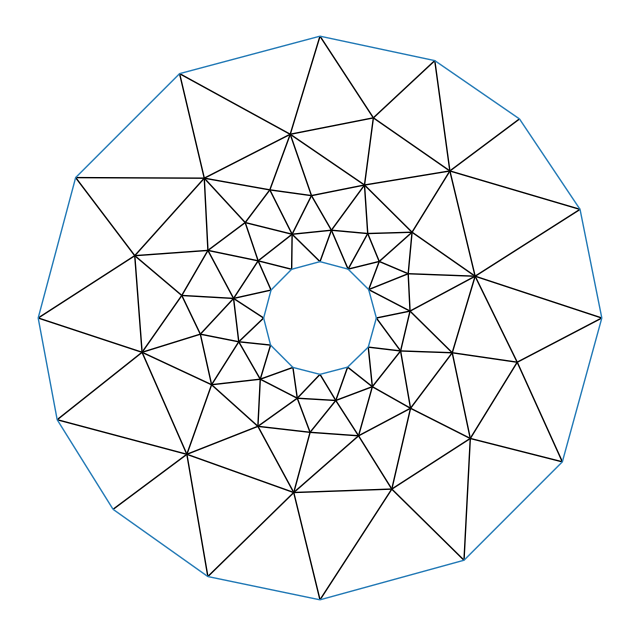

In [3]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [4]:
Boundaries = mesh.boundaries
list(Boundaries)

[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

In [5]:
mesh.curve_boundary(Boundaries.SIGMA, radius=R)
mesh.curve_boundary(Boundaries.D_OMEGA, radius=r)

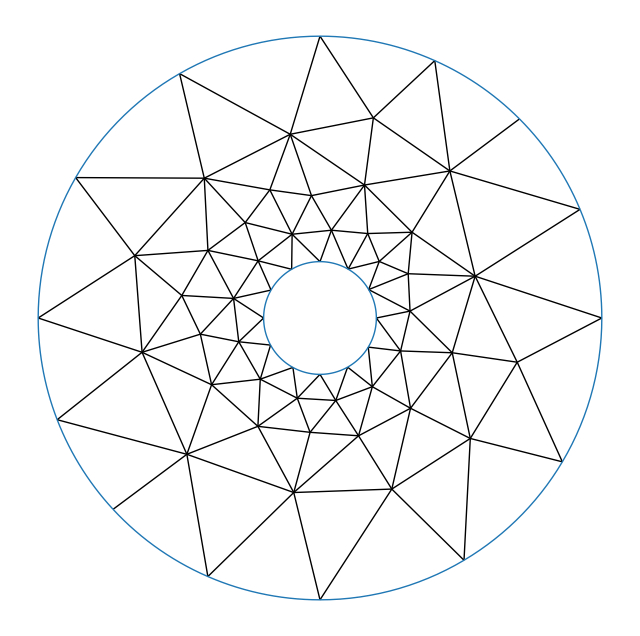

In [6]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [7]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [8]:
import numpy as np
from trefftz.dg.exact import PlaneWave
data = PlaneWave(d=np.array([-1., 0.]), A=-1.)
boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=None), Boundaries.D_OMEGA: DirichletBC(data=data)}
# boundary_conditions = {Regions.SIGMA: DirichletBC(data=data),}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [9]:
# from trefftz.dg.serial_fluxes import UltraWeakFlux, DirichletFlux
from trefftz.dg.block_fluxes import UltraWeakFlux, DirichletFlux


as well as specific ones (for a circular NtD map):

In [10]:
# from cases.open_space.serial_fluxes import NtDLocal, NtDNonLocal
from cases.open_space.block_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [11]:
from trefftz.dg.assemblers import BlockNumerics
NtD_modes = 9
a = 0.5
b = 0.5
d2 = 0.5
numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=None)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = None)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data)},
#                           nonlocal_boundary_kernels={})

We should also choose a local basis

In [12]:
from trefftz.dg.basis import LinearlySpacedBasis
from trefftz.dg.parameters import Elementwise

Regions = mesh.regions


refractive_index = Elementwise(mesh, {Regions.BACKGROUND: 1., Regions.OMEGA : 1.})
k = 8.0
Ntheta = 14
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, refractive_index=refractive_index, k=k, N_theta=Ntheta)

and an assembler:

In [13]:
basis.N_DOF

1484

In [14]:
from trefftz.dg.assemblers import BlockAssembler

assembler = BlockAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [15]:
assembler._regions_RHS_term

[<Boundaries.D_OMEGA: 'd_Omega'>]

so we can set the problem:

In [16]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [17]:
A = P.assemble_LHS()

assembling local operators
region: Sigma


100%|██████████| 14/14 [00:00<00:00, 22.81edge/s]


region: d_Omega


Interior: 100%|██████████| 146/146 [00:00<00:00, 1234.40edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 14/14 [00:46<00:00,  3.35s/edge]


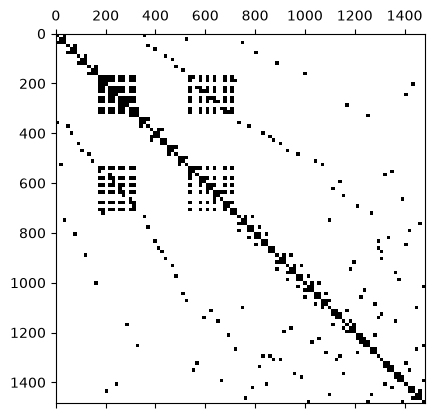

In [18]:
import matplotlib.pyplot as plt 
plt.spy(A.toarray())

In [19]:
b = P.assemble_RHS()

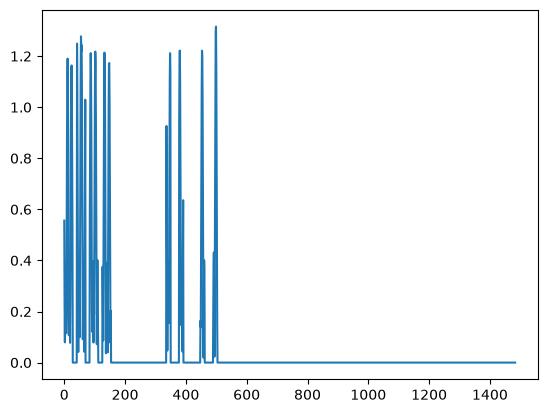

In [20]:
import numpy as np 
plt.plot(np.abs(b))

In [21]:
P.solve()

In [22]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[ 1.02504983e+03+5.72874484e+03j,  3.72673090e+03-4.78749505e+03j,
        -6.33212859e+03+1.14449739e+03j, ...,
        -6.18504608e+03+1.44689291e+03j,  5.93440537e+03+1.48473875e+02j,
        -4.73149261e+03-3.28308359e+03j],
       [ 3.64394659e+03+5.33534872e+03j,  8.35018120e+02-6.57834764e+03j,
        -3.84514202e+03+5.61338036e+03j, ...,
        -2.16706928e+03+5.88465437e+03j,  5.00596851e+03-3.73985920e+03j,
        -6.26159754e+03-8.70462577e+02j],
       [ 4.23890799e+03-2.04242656e+03j, -4.15481432e+03-2.09879677e+03j,
         1.75216149e+03+4.27394376e+03j, ...,
         4.21823326e+03+2.43632956e+03j, -2.68150490e+03-3.99940731e+03j,
        -8.68402497e+02+4.67995251e+03j],
       ...,
       [-1.74027958e+00-1.19554011e-01j, -1.50036012e-01+1.80781957e+00j,
         1.76952411e+00-8.38262404e-01j, ...,
         2.70279567e-01+2.15202541e+00j,  1.83198541e+00-6.37448286e-01j,
        -3.15338252e-01-1.74282103e+00j],
       [ 7.86371087e-01-3.92923787e+00j, -3.

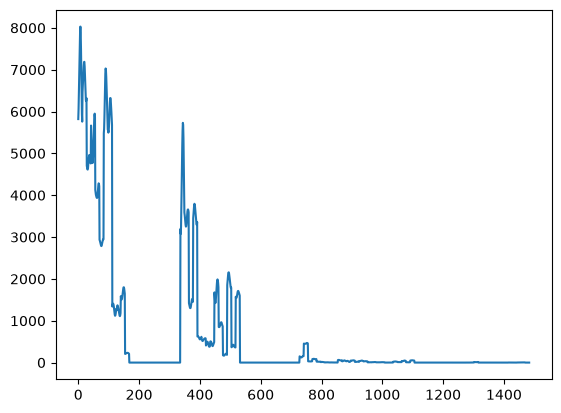

In [23]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

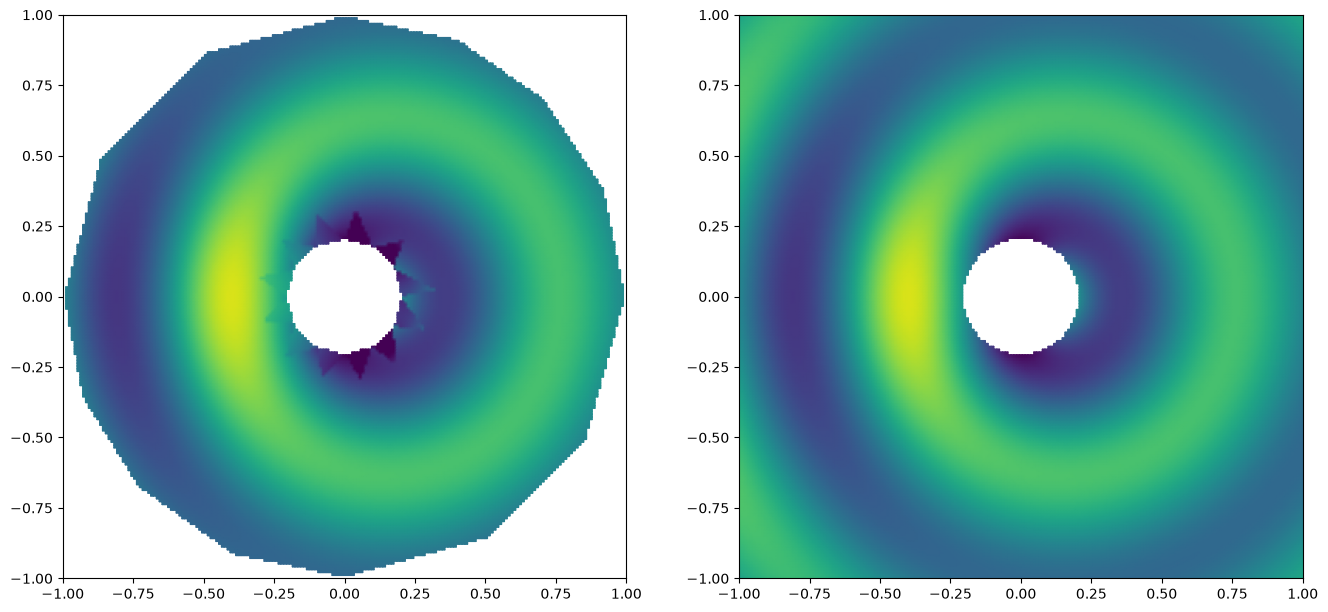

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from cases.open_space.exact import CircularDirichlet

N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

Z = P.u_h(X, Y)
Z_exact = CircularDirichlet(X, Y, R=r, k=k, theta_inc=np.pi)

fig, ax = plt.subplots(ncols=2, figsize=(16,8))
vmin = np.min(Z_exact.real)
vmax = np.max(Z_exact.real)


ax[0].pcolormesh(X, Y, np.real(Z), vmin=-1, vmax=1, shading="gouraud")
ax[0].axis('square')
ax[1].pcolormesh(X, Y, np.real(Z_exact), vmin=-1, vmax=1, shading="gouraud")
ax[1].axis('square')


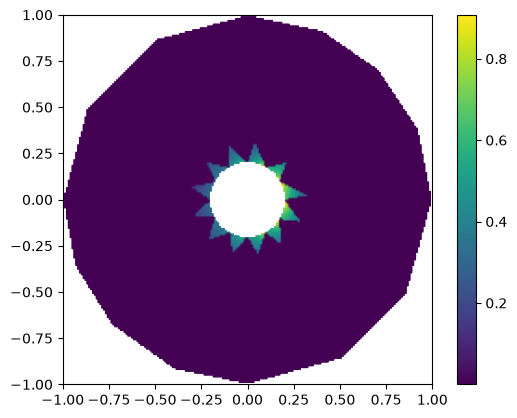

In [25]:
plt.pcolormesh(X, Y, np.abs(Z - Z_exact), shading="gouraud")
plt.axis("square")
plt.colorbar()